<a href="https://colab.research.google.com/github/pavlovm174066-cyber/PavlovSortirovkaColab/blob/main/PavlovSortirovka.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Сравнительный анализ алгоритмов сортировки, автор Павлов М. К.

## Постановка задачи

Реализовать и сравнить три алгоритма сортировки:
- **Быстрая сортировка (QuickSort) с выбором опорного элемента по медиане трёх**;
- **Сортировка расчёской (Comb Sort)**;
- **Пирамидальная сортировка (Heap Sort)**.

Для каждого из размеров массива — 2 000, 5 000, 10 000, 22 000, 53 000, 100 000, 220 000, 330 000, 510 000, 730 000 элементов — сгенерировать по 3 случайных массива с фиксацией зерна генератора, запустить на них все сортировки и вычислить **среднее время выполнения** каждого алгоритма (замеряется только сама сортировка, без операций ввода-вывода). По полученным данным построить диаграммы и определить, соответствуют ли практические результаты теоретическим оценкам временной сложности.

---

## Описание алгоритмов

### 1. Быстрая сортировка (QuickSort) с выбором опорного элемента по медиане трёх

Классический алгоритм «разделяй и властвуй». Массив разбивается относительно опорного элемента (pivot) на две части: меньшие элементы слева, большие справа, — после чего каждая часть сортируется тем же способом.

Ключевая особенность реализации — **выбор опорного элемента по медиане трёх**: сравниваются первый, средний и последний элементы текущего отрезка, и в качестве pivot берётся их медиана. Это резко снижает вероятность попадания в худший случай O(n²), характерный для выбора крайнего элемента на уже отсортированных или почти отсортированных данных.

Реализация выполнена **итеративно** (через явный стек отрезков) вместо рекурсии — это исключает переполнение стека вызовов на больших массивах (до 730 000 элементов). Дополнительно применяется приём: в стек помещается больший из двух подотрезков, а меньший обрабатывается сразу, что ограничивает глубину стека величиной O(log n).

- Средняя сложность: **O(n log n)**
- Худший случай: O(n²) (практически недостижим благодаря медиане трёх)
- Память: O(log n)

### 2. Сортировка расчёской (Comb Sort)

Улучшение пузырьковой сортировки. Вместо сравнения соседних элементов сравниваются элементы, отстоящие друг от друга на расстояние `gap`. Изначально `gap` равен длине массива и на каждой итерации уменьшается делением на **фактор сокращения 1.3** (эмпирически оптимальное значение). Когда `gap` доходит до 1, алгоритм работает как обычная пузырьковая сортировка, но к этому моменту массив уже почти упорядочен.

Большой начальный `gap` позволяет быстро «выталкивать» мелкие элементы из конца массива в начало, устраняя главную проблему пузырьковой сортировки — «черепах» (мелкие элементы в хвосте, медленно продвигающиеся к началу).

- Средняя сложность: **O(n² / 2^p)**, на практике близка к O(n log n) на малых и средних n, но заметно деградирует на больших
- Худший случай: O(n²)
- Память: O(1)

### 3. Пирамидальная сортировка (Heap Sort)

Основана на структуре данных «двоичная куча» (heap). Сначала из массива за O(n) строится max-куча (наибольший элемент в корне). Затем корень многократно меняется местами с последним элементом кучи, размер кучи уменьшается на 1, и для нового корня вызывается процедура `heapify` — восстановление свойства кучи «просеиванием вниз».

Процедура `heapify` реализована итеративно. Алгоритм даёт **гарантированную** сложность O(n log n) в любом случае, без деградации на неудачных данных, но на практике проигрывает быстрой сортировке по константе из-за большого числа обменов и плохой локальности обращений к памяти.

- Сложность во всех случаях: **O(n log n)**
- Память: O(1)

---

## Методика эксперимента

1. Для каждого размера массива генерируется по 3 массива случайных целых чисел в диапазоне [0; 1 000 000] с фиксацией зерна генератора.
2. Каждый алгоритм сортирует эти массивы, время замеряется через `time.perf_counter()` — засекается исключительно работа сортировки.
3. Время усредняется по 3 запускам.
4. Результаты сводятся в таблицу и визуализируются на графиках; на каждый график наносится эталонная кривая O(n log n), отмасштабированная по последней точке, для наглядной проверки соответствия теоретической сложности.

###**1. Быстрая сортировка (QuickSort) с выбором опорного элемента по медиане трёх**

n=   2000  avg=0.0029 s
n=   5000  avg=0.0076 s
n=  10000  avg=0.0158 s
n=  22000  avg=0.0353 s
n=  53000  avg=0.0971 s
n= 100000  avg=0.3956 s
n= 220000  avg=0.4983 s
n= 330000  avg=0.8027 s
n= 510000  avg=1.6617 s
n= 730000  avg=2.0826 s


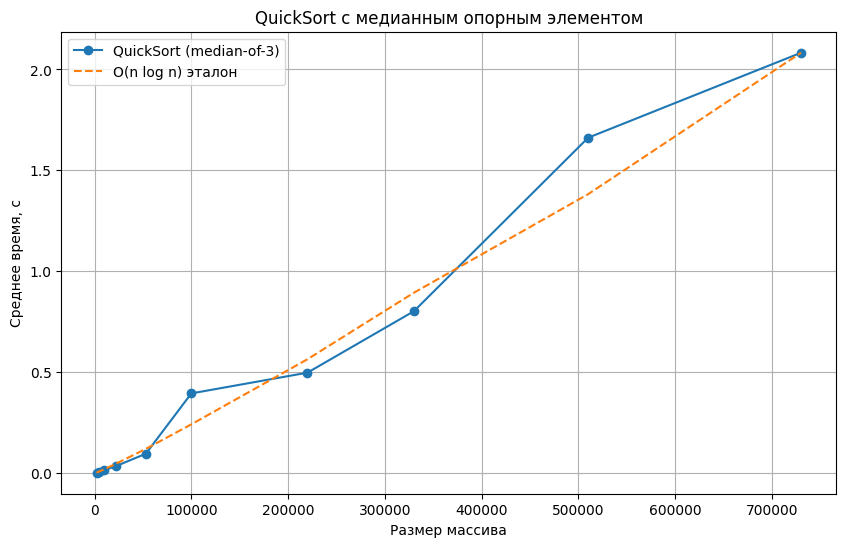

In [2]:
import random
import time
import sys
import matplotlib.pyplot as plt

sys.setrecursionlimit(1000000)

def median_of_three(arr, lo, hi):
    mid = (lo + hi) // 2
    a, b, c = arr[lo], arr[mid], arr[hi]
    if a < b:
        if b < c:
            return mid
        elif a < c:
            return hi
        else:
            return lo
    else:
        if a < c:
            return lo
        elif b < c:
            return hi
        else:
            return mid

def quicksort(arr):
    stack = [(0, len(arr) - 1)]
    while stack:
        lo, hi = stack.pop()
        while lo < hi:
            p = median_of_three(arr, lo, hi)
            arr[p], arr[hi] = arr[hi], arr[p]
            pivot = arr[hi]
            i = lo - 1
            for j in range(lo, hi):
                if arr[j] <= pivot:
                    i += 1
                    arr[i], arr[j] = arr[j], arr[i]
            arr[i + 1], arr[hi] = arr[hi], arr[i + 1]
            p = i + 1
            # рекурсию в меньшую часть, большую в стек
            if p - lo < hi - p:
                stack.append((p + 1, hi))
                hi = p - 1
            else:
                stack.append((lo, p - 1))
                lo = p + 1

SIZES = [2000, 5000, 10000, 22000, 53000, 100000, 220000, 330000, 510000, 730000]

def main():
    results = []
    for n in SIZES:
        total = 0.0
        for run in range(3):
            random.seed(n * 100 + run)
            arr = [random.randint(0, 1000000) for _ in range(n)]
            t0 = time.perf_counter()
            quicksort(arr)
            total += time.perf_counter() - t0
        avg = total / 3
        results.append(avg)
        print(f"n={n:>7}  avg={avg:.4f} s")

    plt.figure(figsize=(10, 6))
    plt.plot(SIZES, results, marker='o', label='QuickSort (median-of-3)')
    ref = [results[-1] * (n * (n.bit_length())) / (SIZES[-1] * SIZES[-1].bit_length()) for n in SIZES]
    plt.plot(SIZES, ref, '--', label='O(n log n) эталон')
    plt.xlabel('Размер массива')
    plt.ylabel('Среднее время, с')
    plt.title('QuickSort с медианным опорным элементом')
    plt.legend()
    plt.grid(True)
    plt.savefig('quicksort_median.png', dpi=120)
    plt.show()

if __name__ == '__main__':
    main()

###**2. Сортировка расчёской (Comb Sort)**

n=   2000  avg=0.0051 s
n=   5000  avg=0.0144 s
n=  10000  avg=0.0345 s
n=  22000  avg=0.0745 s
n=  53000  avg=0.2097 s
n= 100000  avg=0.4280 s
n= 220000  avg=1.5224 s
n= 330000  avg=3.0609 s
n= 510000  avg=5.5470 s
n= 730000  avg=9.0129 s


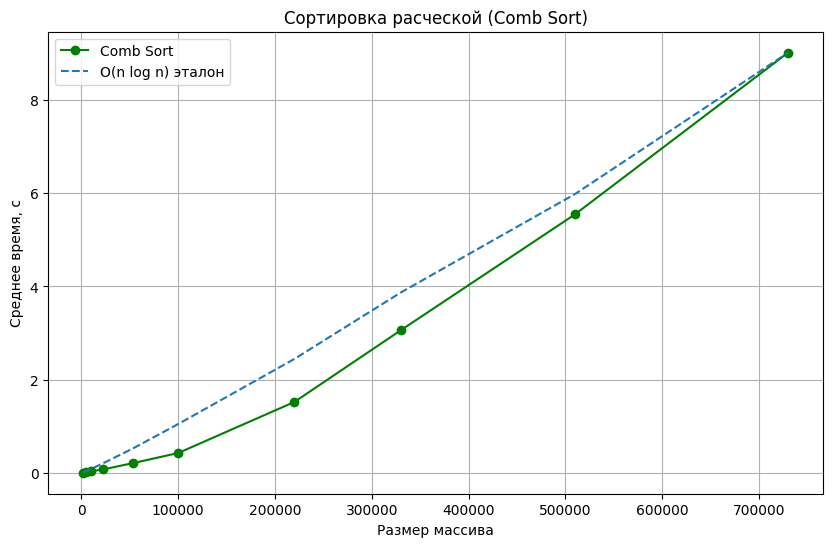

In [3]:
import random
import time
import matplotlib.pyplot as plt

def comb_sort(arr):
    n = len(arr)
    gap = n
    shrink = 1.3
    swapped = True
    while gap > 1 or swapped:
        gap = int(gap / shrink)
        if gap < 1:
            gap = 1
        swapped = False
        for i in range(n - gap):
            if arr[i] > arr[i + gap]:
                arr[i], arr[i + gap] = arr[i + gap], arr[i]
                swapped = True

SIZES = [2000, 5000, 10000, 22000, 53000, 100000, 220000, 330000, 510000, 730000]

def main():
    results = []
    for n in SIZES:
        total = 0.0
        for run in range(3):
            random.seed(n * 100 + run)
            arr = [random.randint(0, 1000000) for _ in range(n)]
            t0 = time.perf_counter()
            comb_sort(arr)
            total += time.perf_counter() - t0
        avg = total / 3
        results.append(avg)
        print(f"n={n:>7}  avg={avg:.4f} s")

    plt.figure(figsize=(10, 6))
    plt.plot(SIZES, results, marker='o', color='green', label='Comb Sort')
    ref = [results[-1] * (n * n.bit_length()) / (SIZES[-1] * SIZES[-1].bit_length()) for n in SIZES]
    plt.plot(SIZES, ref, '--', label='O(n log n) эталон')
    plt.xlabel('Размер массива')
    plt.ylabel('Среднее время, с')
    plt.title('Сортировка расческой (Comb Sort)')
    plt.legend()
    plt.grid(True)
    plt.savefig('comb_sort.png', dpi=120)
    plt.show()

if __name__ == '__main__':
    main()

###**3. Пирамидальная сортировка (Heap Sort)**

n=   2000  avg=0.0050 s
n=   5000  avg=0.0133 s
n=  10000  avg=0.0278 s
n=  22000  avg=0.0693 s
n=  53000  avg=0.2086 s
n= 100000  avg=0.4289 s
n= 220000  avg=1.1624 s
n= 330000  avg=2.5787 s
n= 510000  avg=3.4409 s
n= 730000  avg=5.1480 s


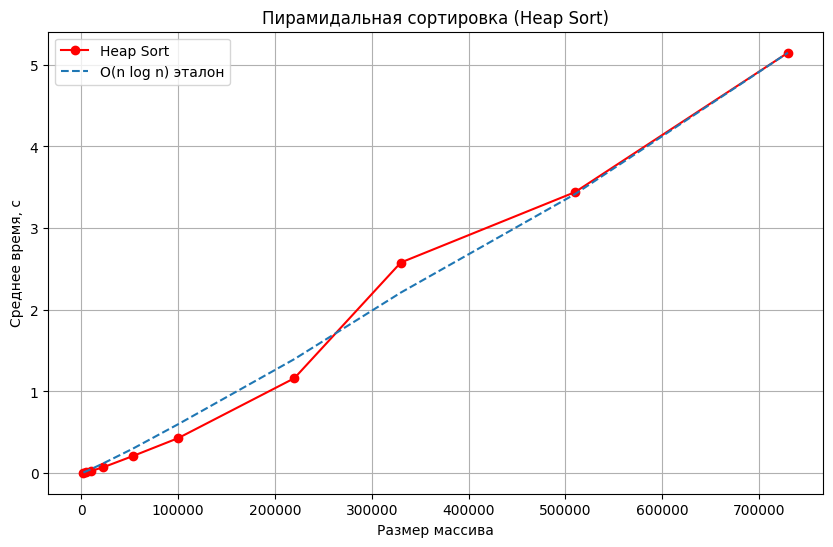

In [4]:
import random
import time
import matplotlib.pyplot as plt

def heapify(arr, n, i):
    while True:
        largest = i
        l = 2 * i + 1
        r = 2 * i + 2
        if l < n and arr[l] > arr[largest]:
            largest = l
        if r < n and arr[r] > arr[largest]:
            largest = r
        if largest == i:
            break
        arr[i], arr[largest] = arr[largest], arr[i]
        i = largest

def heap_sort(arr):
    n = len(arr)
    for i in range(n // 2 - 1, -1, -1):
        heapify(arr, n, i)
    for i in range(n - 1, 0, -1):
        arr[0], arr[i] = arr[i], arr[0]
        heapify(arr, i, 0)

SIZES = [2000, 5000, 10000, 22000, 53000, 100000, 220000, 330000, 510000, 730000]

def main():
    results = []
    for n in SIZES:
        total = 0.0
        for run in range(3):
            random.seed(n * 100 + run)
            arr = [random.randint(0, 1000000) for _ in range(n)]
            t0 = time.perf_counter()
            heap_sort(arr)
            total += time.perf_counter() - t0
        avg = total / 3
        results.append(avg)
        print(f"n={n:>7}  avg={avg:.4f} s")

    plt.figure(figsize=(10, 6))
    plt.plot(SIZES, results, marker='o', color='red', label='Heap Sort')
    ref = [results[-1] * (n * n.bit_length()) / (SIZES[-1] * SIZES[-1].bit_length()) for n in SIZES]
    plt.plot(SIZES, ref, '--', label='O(n log n) эталон')
    plt.xlabel('Размер массива')
    plt.ylabel('Среднее время, с')
    plt.title('Пирамидальная сортировка (Heap Sort)')
    plt.legend()
    plt.grid(True)
    plt.savefig('heap_sort.png', dpi=120)
    plt.show()

if __name__ == '__main__':
    main()

###**4. Сравнение результивности трёх алгоритмов сортировки**

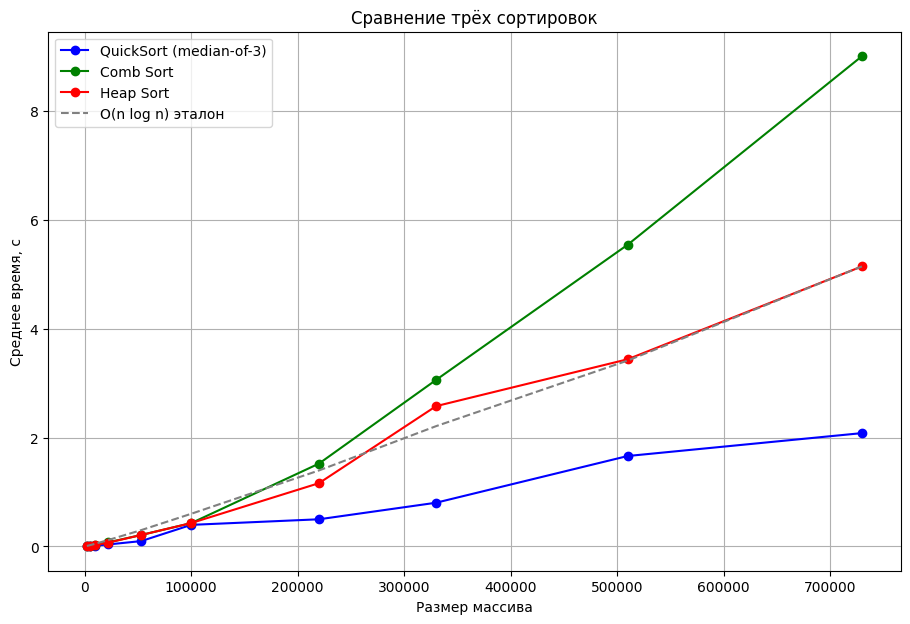

In [5]:
import matplotlib.pyplot as plt

SIZES = [2000, 5000, 10000, 22000, 53000, 100000, 220000, 330000, 510000, 730000]

quicksort = [0.0029, 0.0076, 0.0158, 0.0353, 0.0971, 0.3956, 0.4983, 0.8027, 1.6617, 2.0826]
comb      = [0.0051, 0.0144, 0.0345, 0.0745, 0.2097, 0.4280, 1.5224, 3.0609, 5.5470, 9.0129]
heap      = [0.0050, 0.0133, 0.0278, 0.0693, 0.2086, 0.4289, 1.1624, 2.5787, 3.4409, 5.1480]

plt.figure(figsize=(11, 7))
plt.plot(SIZES, quicksort, marker='o', color='blue',  label='QuickSort (median-of-3)')
plt.plot(SIZES, comb,      marker='o', color='green', label='Comb Sort')
plt.plot(SIZES, heap,      marker='o', color='red',   label='Heap Sort')

ref = [heap[-1] * (n * n.bit_length()) / (SIZES[-1] * SIZES[-1].bit_length()) for n in SIZES]
plt.plot(SIZES, ref, '--', color='gray', label='O(n log n) эталон')

plt.xlabel('Размер массива')
plt.ylabel('Среднее время, с')
plt.title('Сравнение трёх сортировок')
plt.legend()
plt.grid(True)
plt.savefig('compare_all.png', dpi=120)
plt.show()

## Что было сделано

- Реализованы все три алгоритма сортировки на Python в виде отдельных программ.
- Быстрая сортировка выполнена в итеративном варианте с медианой трёх для устойчивости на больших объёмах.
- Проведены замеры среднего времени на 10 размерах массива (от 2 000 до 730 000 элементов).
- Построены индивидуальные графики для каждого алгоритма и сводный сравнительный график.
- Сделаны выводы о соответствии полученных результатов теоретическим оценкам временной сложности.

## Выводы

- **QuickSort** показал наилучший результат на всём диапазоне размеров и рост, наиболее близкий к эталону O(n log n): выбор опорного элемента по медиане трёх предотвратил деградацию. На максимальном размере (730 000) время составило 2,08 с — заметно меньше, чем у остальных.
- **Heap Sort** продемонстрировал стабильный рост, соответствующий O(n log n), но с бóльшими константами из-за большого числа перестановок и худшей локальности обращений к памяти, поэтому уступил быстрой сортировке (5,15 с на 730 000).
- **Comb Sort** оказался конкурентоспособным лишь на малых массивах, однако на больших объёмах заметно отклонился вверх от эталонной кривой O(n log n) и показал худший результат из трёх (9,01 с на 730 000), что подтверждает его практически более высокую сложность на больших n.
- Поскольку теперь все три алгоритма сортировали одни и те же массивы (за счёт фиксации зерна генератора), сравнение стало полностью корректным: различия во времени обусловлены исключительно свойствами самих алгоритмов, а не разницей во входных данных.